In [1]:
import pandas as pd
import plotnine as pn
from pathlib import Path
import numpy as np
import os
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import beta
import seaborn as sns

import matplotlib.pyplot as plt
from itables import init_notebook_mode

init_notebook_mode(all_interactive=True)

%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *


In [2]:

shared_outliers = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/shared_outliers/shared_rna_protein_predisposition_outliers.tsv", sep="\t")

In [3]:
shared_outliers

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [3]:
sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")


In [4]:
pr_output_name = "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"
pr_res_all = load_pr_data("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/protrider_summary.csv")

py_or_res_all = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/protrider_summary.csv")

py_or_res_all = pd.merge(py_or_res_all, sa, left_on="sampleID", right_on="pid")
py_or_res_all["geneID_short"] = py_or_res_all["geneID"].str.split(".").str[0]
py_or_res_all["expressed_in_cohort"] = False
py_or_res_all["gene_sample"] = py_or_res_all["geneID"] + "_" + py_or_res_all["sampleID"]


In [ ]:
or_res_all = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/outrider/aggregated_or_res_all.tsv", sep="\t")
or_res_all = or_res_all.sort_values("pValue")
or_res_all["geneID_short"] = or_res_all["geneID"].str.split(".").str[0]


or_res_outliers_all = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/outrider/aggregated_outliers.tsv", sep="\t")
or_res_outliers_all["geneID_short"] = or_res_outliers_all["geneID"].str.split(".").str[0]




### Read in variants

In [5]:
variant_base_path = Path("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/")
benchmark_criteria = "HIGH"

# Read tables
snv_vep_res = pd.read_csv(
    variant_base_path / f"vep_res_rare_snv_{benchmark_criteria}_aggregated_variant_type.tsv",
    sep="\t"
)
indel_vep_res = pd.read_csv(
    variant_base_path / f"vep_res_rare_indel_{benchmark_criteria}_aggregated_variant_type.tsv",
    sep="\t"
)

# Combine
vep_res_combined = pd.concat([snv_vep_res, indel_vep_res], ignore_index=True)

print(len(vep_res_combined))

# Unique_based_on_criteria
if benchmark_criteria == "CADD_PHRED":
    # Sort decreasing by CADD_PHRED
    vep_res_combined = (
        snv_vep_res.sort_values("CADD_PHRED", ascending=False)
        .groupby(["sampleID", "Gene"])
        .head(1)
        .reset_index(drop=True)
    )
# elif benchmark_criteria == "VEP_splice":
#   vep_res_combinded = vep_res_combinded[vep_res_combinded["Consequence"].str.contains("splic", na=False)]
#   vep_res_combinded <- vep_res_combinded[, IMPACT := factor(IMPACT, levels = c("HIGH", "MODERATE", "LOW", "MODIFIER"), ordered = TRUE)]
#   setorder(vep_res_combinded, Gene, sampleID, IMPACT)
else:
    # Set IMPACT as ordered category and sort
    impact_order = ["HIGH", "MODERATE", "LOW", "MODIFIER"]
    vep_res_combined["IMPACT"] = pd.Categorical(
        vep_res_combined["IMPACT"],
        categories=impact_order,
        ordered=True
    )

    vep_res_combined = (
        vep_res_combined.sort_values(["Gene", "sampleID", "IMPACT"])
    )

# Remove duplicates by Gene + sampleID, keeping first (like data.table)
vep_res_combined = (
    vep_res_combined.drop_duplicates(subset=["Gene", "sampleID"])
)
print(len(vep_res_combined))

664718
224131


In [4]:
vep_res_combined

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [ ]:
variant_base_path = Path("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/")
benchmark_criteria = "all_aggregated_unique"

# Read tables
snv_vep_res = pd.read_csv(
    variant_base_path / f"vep_res_rare_snv_{benchmark_criteria}_variant_type.tsv",
    sep="\t"
)
indel_vep_res = pd.read_csv(
    variant_base_path / f"vep_res_rare_indel_{benchmark_criteria}_variant_type.tsv",
    sep="\t"
)

# Combine
vep_res_combined_all = pd.concat([snv_vep_res, indel_vep_res], ignore_index=True)

print(len(vep_res_combined_all))

# Unique_based_on_criteria
if benchmark_criteria == "CADD_PHRED":
    # Sort decreasing by CADD_PHRED
    vep_res_combined = (
        snv_vep_res.sort_values("CADD_PHRED", ascending=False)
        .groupby(["sampleID", "Gene"])
        .head(1)
        .reset_index(drop=True)
    )
# elif benchmark_criteria == "VEP_splice":
#   vep_res_combinded = vep_res_combinded[vep_res_combinded["Consequence"].str.contains("splic", na=False)]
#   vep_res_combinded <- vep_res_combinded[, IMPACT := factor(IMPACT, levels = c("HIGH", "MODERATE", "LOW", "MODIFIER"), ordered = TRUE)]
#   setorder(vep_res_combinded, Gene, sampleID, IMPACT)
else:
    # Set IMPACT as ordered category and sort
    impact_order = ["HIGH", "MODERATE", "LOW", "MODIFIER"]
    vep_res_combined_all["IMPACT"] = pd.Categorical(
        vep_res_combined_all["IMPACT"],
        categories=impact_order,
        ordered=True
    )

    vep_res_combined_all = (
        vep_res_combined_all.sort_values(["Gene", "sampleID", "IMPACT"])
    )

# Remove duplicates by Gene + sampleID, keeping first (like data.table)
vep_res_combined_all = (
    vep_res_combined_all.drop_duplicates(subset=["Gene", "sampleID"])
)
print(len(vep_res_combined_all))

/tmp/ipykernel_2336322/1258125529.py:5: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.


In [ ]:
variant_base_path = Path("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/")
benchmark_criteria = "VEP_splice"

# Read tables
snv_vep_res = pd.read_csv(
    variant_base_path / f"vep_res_rare_snv_{benchmark_criteria}_aggregated_variant_type.tsv",
    sep="\t"
)
indel_vep_res = pd.read_csv(
    variant_base_path / f"vep_res_rare_indel_{benchmark_criteria}_aggregated_variant_type.tsv",
    sep="\t"
)

# Combine
vep_res_combined_splice = pd.concat([snv_vep_res, indel_vep_res], ignore_index=True)

print(len(vep_res_combined_splice))

# Unique_based_on_criteria
if benchmark_criteria == "CADD_PHRED":
    # Sort decreasing by CADD_PHRED
    vep_res_combined_splice = (
        snv_vep_res.sort_values("CADD_PHRED", ascending=False)
        .groupby(["sampleID", "Gene"])
        .head(1)
        .reset_index(drop=True)
    )
elif benchmark_criteria == "VEP_splice":
    vep_res_combined_splice = vep_res_combined_splice[vep_res_combined_splice["Consequence"].str.contains("splic", na=False)]
    # Set ordered categorical levels for IMPACT
    impact_order = ["HIGH", "MODERATE", "LOW", "MODIFIER"]
    vep_res_combined_splice["IMPACT"] = pd.Categorical(
        vep_res_combined_splice["IMPACT"],
        categories=impact_order,
        ordered=True
    )

    # Sort by Gene, sampleID, IMPACT
    vep_res_combined_splice = vep_res_combined_splice.sort_values(["Gene", "sampleID", "IMPACT"])
else:
    # Set IMPACT as ordered category and sort
    impact_order = ["HIGH", "MODERATE", "LOW", "MODIFIER"]
    vep_res_combined_splice["IMPACT"] = pd.Categorical(
        vep_res_combined_splice["IMPACT"],
        categories=impact_order,
        ordered=True
    )

    vep_res_combined_splice = (
        vep_res_combined_splice.sort_values(["Gene", "sampleID", "IMPACT"])
    )

# Remove duplicates by Gene + sampleID, keeping first (like data.table)
vep_res_combined_splice = (
    vep_res_combined_splice.drop_duplicates(subset=["Gene", "sampleID"])
)
print(len(vep_res_combined_splice))

In [13]:
variant_base_path = Path("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/")
benchmark_criteria = "PROTRIDER"

# Read tables
snv_vep_res = pd.read_csv(
    variant_base_path / f"vep_res_rare_snv_{benchmark_criteria}_aggregated_variant_type.tsv",
    sep="\t"
)
indel_vep_res = pd.read_csv(
    variant_base_path / f"vep_res_rare_indel_{benchmark_criteria}_aggregated_variant_type.tsv",
    sep="\t"
)

# Combine
vep_res_combined_protrider = pd.concat([snv_vep_res, indel_vep_res], ignore_index=True)

print(len(vep_res_combined_protrider))

# Unique_based_on_criteria
if benchmark_criteria == "CADD_PHRED":
    # Sort decreasing by CADD_PHRED
    vep_res_combined_protrider = (
        snv_vep_res.sort_values("CADD_PHRED", ascending=False)
        .groupby(["sampleID", "Gene"])
        .head(1)
        .reset_index(drop=True)
    )
else:
    # Set IMPACT as ordered category and sort
    impact_order = ["HIGH", "MODERATE", "LOW", "MODIFIER"]
    vep_res_combined_protrider["IMPACT"] = pd.Categorical(
        vep_res_combined_protrider["IMPACT"],
        categories=impact_order,
        ordered=True
    )

    vep_res_combined_protrider = (
        vep_res_combined_protrider.sort_values(["Gene", "sampleID", "IMPACT"])
    )

# Remove duplicates by Gene + sampleID, keeping first (like data.table)
vep_res_combined_protrider = (
    vep_res_combined_protrider.drop_duplicates(subset=["Gene", "sampleID"])
)
print(len(vep_res_combined_protrider))

/tmp/ipykernel_3437110/796723460.py:5: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.


5806856
1745352


### merge results with variants

In [31]:
pr_res_all = pd.merge(pr_res_all, vep_res_combined_protrider[["Gene", "sampleID", "IMPACT", "Consequence", "ANNOTATION_control"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")
pr_res_all["IMPACT_bool"] = pr_res_all["IMPACT"] == "HIGH"

pr_res_aberrant = pr_res_all[pr_res_all["padjust"] <= 0.1]
pr_res_aberrant = pd.merge(pr_res_aberrant, sa, left_on="sampleID", right_on="pid", how="left")


### COAD samples

In [ ]:
coad_q_oht = pd.read_csv("//omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/coad/oht_cov_diag_lr_0_0001_epoc200_gpu/protrider_summary.csv.gz")
coad_q_12 = pd.read_csv("//omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/coad/q12_lr_0_0001_epoc200_gpu/protrider_summary.csv.gz")

py_or_res_all_coad = py_or_res_all[py_or_res_all["Diag"] == "COAD"]

coad_q_oht["geneID_short"] = coad_q_oht["geneID"].str.split(".").str[0]
coad_q_oht["gene_sample"] = coad_q_oht["geneID"] + "_" + coad_q_oht["sampleID"]

coad_q_12["geneID_short"] = coad_q_12["geneID"].str.split(".").str[0]
coad_q_12["gene_sample"] = coad_q_12["geneID"] + "_" + coad_q_12["sampleID"]

coad_or_res = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/outrider/COAD/OUTRIDER_results_all.tsv", sep="\t")
coad_or_res["gene_sample"] = coad_or_res["geneID"] + "_" + coad_or_res["sampleID"]
coad_or_res["geneID_short"] = coad_or_res["geneID"].str.split(".").str[0]



In [ ]:
coad_q_oht = pd.merge(coad_q_oht, vep_res_combined[["Gene", "sampleID", "IMPACT", "Consequence"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")
coad_q_12 = pd.merge(coad_q_12, vep_res_combined[["Gene", "sampleID", "IMPACT", "Consequence"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")

coad_q_oht["IMPACT_bool"] = coad_q_oht["IMPACT"] == "HIGH"
coad_q_12["IMPACT_bool"] = coad_q_12["IMPACT"] == "HIGH"

coad_or_res = pd.merge(coad_or_res, vep_res_combined[["Gene", "sampleID", "IMPACT", "Consequence"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")
coad_or_res["IMPACT_bool"] = coad_or_res["IMPACT"] == "HIGH"

coad_or_res = coad_or_res.sort_values("pValue")
coad_q_12 = coad_q_12.sort_values("pValue")
coad_q_oht = coad_q_oht.sort_values("pValue")





In [ ]:
py_or_res_all_coad = pd.merge(py_or_res_all_coad, vep_res_combined[["Gene", "sampleID", "IMPACT", "Consequence"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")
py_or_res_all_coad["IMPACT_bool"] = py_or_res_all_coad["IMPACT"] == "HIGH"

py_or_res_all_coad = py_or_res_all_coad.sort_values("pValue")

### FRASER results

In [20]:
fr_res_gene = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_outliers.tsv", sep="\t")
fr_res_gene = pd.merge(fr_res_gene, sa, left_on="sampleID", right_on="pid")
fr_res_gene = fr_res_gene.merge(gene_annot_dt[["gene_name", "geneID_short", "gene_id"]], how="left", left_on="hgncSymbol", right_on="gene_name")

fr_res_gene = fr_res_gene.rename(columns={"gene_id":"geneID"})

In [68]:
fr_res_gene = pd.merge(fr_res_gene, vep_res_combined_splice[["Gene", "sampleID", "IMPACT", "Consequence"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")
fr_res_gene_aberrant_predisposed_all = pd.merge(fr_res_gene, dresden_dt_cgc[["gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], on="geneID_short", how="left")

cols = ["nct_pid", "Oncotree Code", "geneID"] + list(fr_res_gene_aberrant_predisposed_all.columns[:12]) +["annotatedJunction", "potentialImpact", "causesFrameshift", "IMPACT", "Consequence", "ROLE_IN_CANCER", "predisposition_gene", "RNA_BAM_FILE"]


fr_res_gene_aberrant_predisposed_all[cols].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/py_outrider/gene_splicing_outliers.tsv", sep="\t", index=None)


fr_res_gene_aberrant_predisposed = fr_res_gene_aberrant_predisposed_all[fr_res_gene_aberrant_predisposed_all["predisposition_gene"] == True]

fr_res_gene_aberrant_predisposed[cols].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/py_outrider/gene_splicing_predisposition_outliers.tsv", sep="\t", index=None)


In [ ]:
fr_res_gene_aberrant_predisposed_all = pd.merge(fr_res_gene, dresden_dt_cgc[["gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], on="geneID_short", how="left")

cols = ["nct_pid", "Oncotree Code", "geneID"] + list(fr_res_gene_aberrant_predisposed_all.columns[:12]) +["annotatedJunction", "potentialImpact", "causesFrameshift", "IMPACT", "Consequence", "ROLE_IN_CANCER", "predisposition_gene", "RNA_BAM_FILE"]


fr_res_gene_aberrant_predisposed_all[cols].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/py_outrider/gene_splicing_outliers.tsv", sep="\t", index=None)


fr_res_gene_aberrant_predisposed = fr_res_gene_aberrant_predisposed_all[fr_res_gene_aberrant_predisposed_all["predisposition_gene"] == True]

fr_res_gene_aberrant_predisposed[cols].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/py_outrider/gene_splicing_predisposition_outliers.tsv", sep="\t", index=None)


In [58]:
fr_res_junction = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_results_per_junction.tsv", sep="\t")

fr_res_junction = pd.merge(fr_res_junction, sa, left_on="sampleID", right_on="pid")


fr_re_junction_notna = fr_res_junction[(fr_res_junction["hgncSymbol"].notna())]
fr_re_junction_notna = fr_re_junction_notna.sort_values("pValue")


fr_re_junction_notna = pd.merge(fr_re_junction_notna, vep_res_combined_splice[["Gene", "sampleID", "IMPACT", "Consequence"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")


In [61]:
fr_re_junction_notna_predisposed_all = pd.merge(fr_re_junction_notna, dresden_dt_cgc[["gene_type", "geneID", "ROLE_IN_CANCER", "predisposition_gene"]], on="geneID", how="left")
cols = ["nct_pid", "Oncotree Code", "geneID"] + list(fr_re_junction_notna_predisposed_all.columns[:12]) +["annotatedJunction", "potentialImpact", "causesFrameshift", "IMPACT", "Consequence", "ROLE_IN_CANCER", "predisposition_gene", "RNA_BAM_FILE"]

fr_re_junction_notna_predisposed_all[cols].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/gene_splicing_outlier_junctions.tsv", sep="\t", index=None)


fr_res_gene_aberrant_predisposed = fr_re_junction_notna_predisposed_all[fr_re_junction_notna_predisposed_all["predisposition_gene"] == True]

fr_res_gene_aberrant_predisposed[cols].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/gene_splicing_predisposition_outlier_junctions.tsv", sep="\t", index=None)





### OUTRIDER results

In [16]:
py_or_res_all = pd.merge(py_or_res_all, vep_res_combined[["Gene", "sampleID", "IMPACT", "Consequence"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")
py_or_res_all["IMPACT_bool"] = py_or_res_all["IMPACT"] == "HIGH"

In [11]:

py_or_res_aberrant = py_or_res_all[py_or_res_all['padjust'] <= 0.05]
py_or_res_aberrant = pd.merge(py_or_res_aberrant, vep_res_combined[["Gene", "sampleID", "IMPACT", "Consequence", "ANNOTATION_control"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")
py_or_res_aberrant["IMPACT_bool"] = py_or_res_aberrant["IMPACT"] == "HIGH"

py_or_res_aberrant_predisposed_all = pd.merge(py_or_res_aberrant, dresden_dt_cgc[["gene_name", "gene_type", "geneID", "ROLE_IN_CANCER", "predisposition_gene"]], on="geneID", how="left")
py_or_res_aberrant_predisposed_all["expression_direction"] = "underexpression"
py_or_res_aberrant_predisposed_all.loc[py_or_res_aberrant_predisposed_all["zScore"] >= 0, "expression_direction"] = "Overexpression"
py_or_res_aberrant_predisposed_all[["sampleID", "geneID", "zScore", "pValue", "padjust", "Oncotree Code", "IMPACT", "Consequence", "gene_name", "ROLE_IN_CANCER", "expression_direction", "nct_pid", "predisposition_gene", "ANNOTATION_control", '#CHROM', 'POS', 'ID']].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/gene_expression_outliers.tsv", sep="\t", index=None)


py_or_res_outliers_predisposed = py_or_res_aberrant_predisposed_all[py_or_res_aberrant_predisposed_all["predisposition_gene"] == True]
py_or_res_outliers_predisposed[["sampleID", "geneID", "zScore", "pValue", "padjust", "Oncotree Code", "IMPACT", "Consequence", "gene_name", "ROLE_IN_CANCER", "expression_direction", "nct_pid", "predisposition_gene", "ANNOTATION_control", '#CHROM', 'POS', 'ID']].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/gene_expression_predisposition_outliers.tsv", sep="\t", index=None)



In [32]:
pr_res_aberrant_predisposed_all = pd.merge(pr_res_aberrant, dresden_dt_cgc[["gene_name", "gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], right_on="geneID_short", left_on="geneID", how="left")
pr_res_aberrant_predisposed_all["expression_direction"] = "underexpression"
pr_res_aberrant_predisposed_all.loc[pr_res_aberrant_predisposed_all["zScore"] >= 0, "expression_direction"] = "Overexpression"
pr_res_aberrant_predisposed_all["geneID"] = pr_res_aberrant_predisposed_all["gene_id"]

#pr_res_aberrant_predisposed_all[[ "nct_pid","proteinID", "geneID", "zScore", "pValue", "padjust", "Oncotree Code", "IMPACT", "Consequence", "ROLE_IN_CANCER", "expression_direction", "predisposition_gene", "sampleID"]].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/py_outrider/protein_expression_outliers.tsv", sep="\t", index=None)




In [36]:
pr_res_aberrant_predisposed_all[(pr_res_aberrant_predisposed_all["predisposition_gene"] == True) & (pr_res_aberrant_predisposed_all["Consequence"].notna())][["sampleID", "Oncotree Code", "proteinID", "Consequence", "ROLE_IN_CANCER", "ANNOTATION_control"]]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [126]:
predisposed_high_impact_pr = pr_res_aberrant_predisposed[
    pr_res_aberrant_predisposed["IMPACT"].notna()
]

counts_pr = (
    predisposed_high_impact_pr['proteinID']
    .value_counts()                     # descending by default
    .reset_index(name='total_count')
    .rename(columns={'index':'proteinID'})
)

# 2) set the categorical order so plot follows the descending counts
counts_pr['proteinID'] = pd.Categorical(
    counts_pr['proteinID'],
    categories=counts_pr['proteinID'],    # already in descending order from value_counts()
    ordered=True
)
sum(counts_pr["total_count"])

19

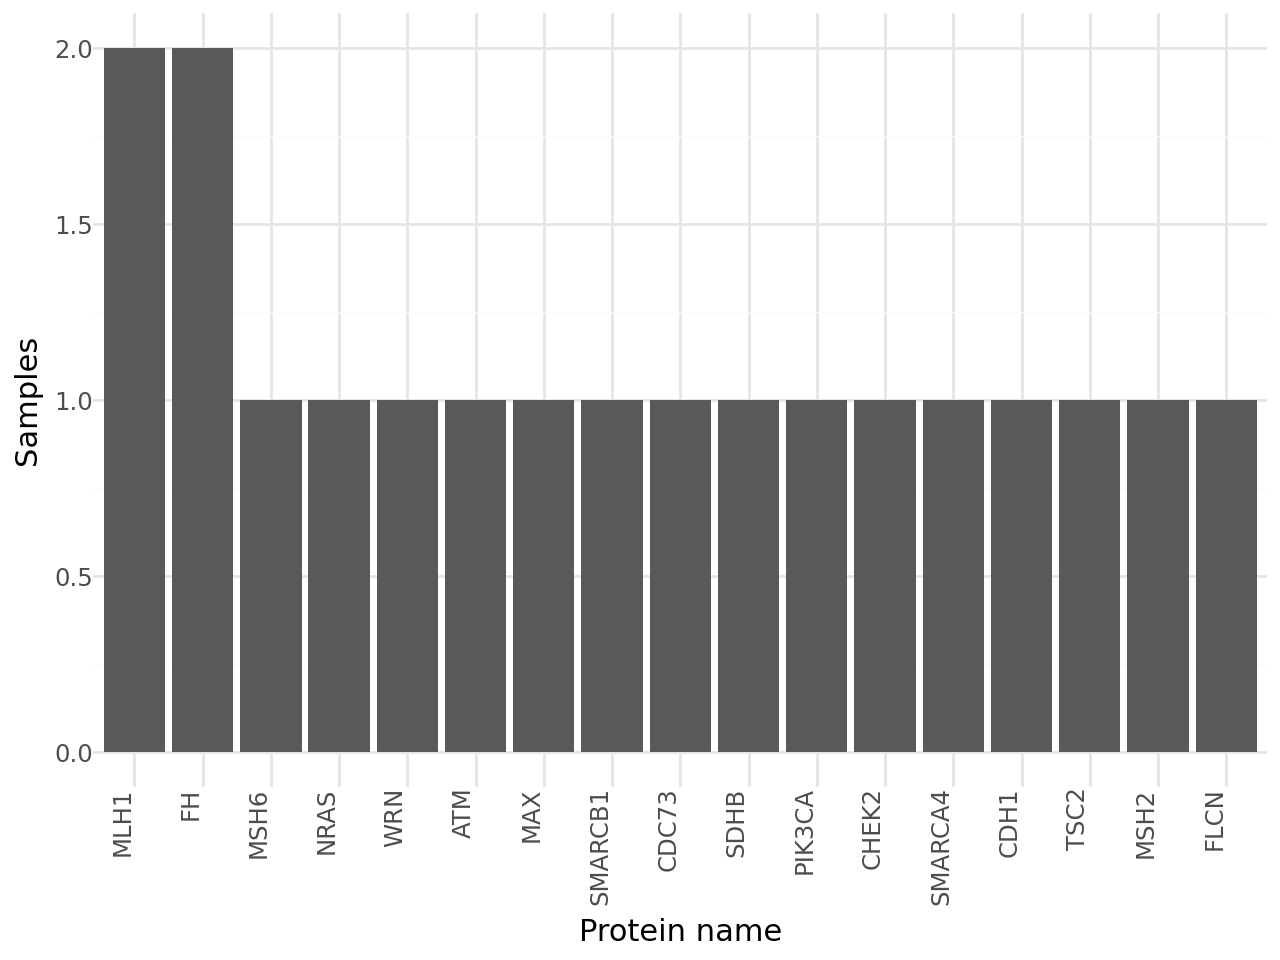

In [125]:
(
    pn.ggplot(counts_pr, pn.aes(x='proteinID', y='total_count')) +
    pn.geom_bar(stat='identity') +
    pn.labs(x= "Protein name", y="Samples") + 
    pn.theme_minimal() +
    pn.theme(axis_text_x=pn.element_text(rotation=90, hjust=1))
)

In [51]:
or_res_outliers_all_predisposed = pd.merge(or_res_outliers_all, dresden_dt_cgc[["gene_name", "gene_type", "geneID", "ROLE_IN_CANCER"]], on="geneID")

predisposed_high_impact = or_res_outliers_all_predisposed[(or_res_outliers_all_predisposed["padjust"] <= 0.05) &(or_res_outliers_all_predisposed["IMPACT_bool"] == True)  ]

counts = (
    predisposed_high_impact['hgncSymbol']
    .value_counts()                     # descending by default
    .reset_index(name='total_count')
    .rename(columns={'index':'hgncSymbol'})
)

# 2) set the categorical order so plot follows the descending counts
counts['hgncSymbol'] = pd.Categorical(
    counts['hgncSymbol'],
    categories=counts['hgncSymbol'],    # already in descending order from value_counts()
    ordered=True
)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


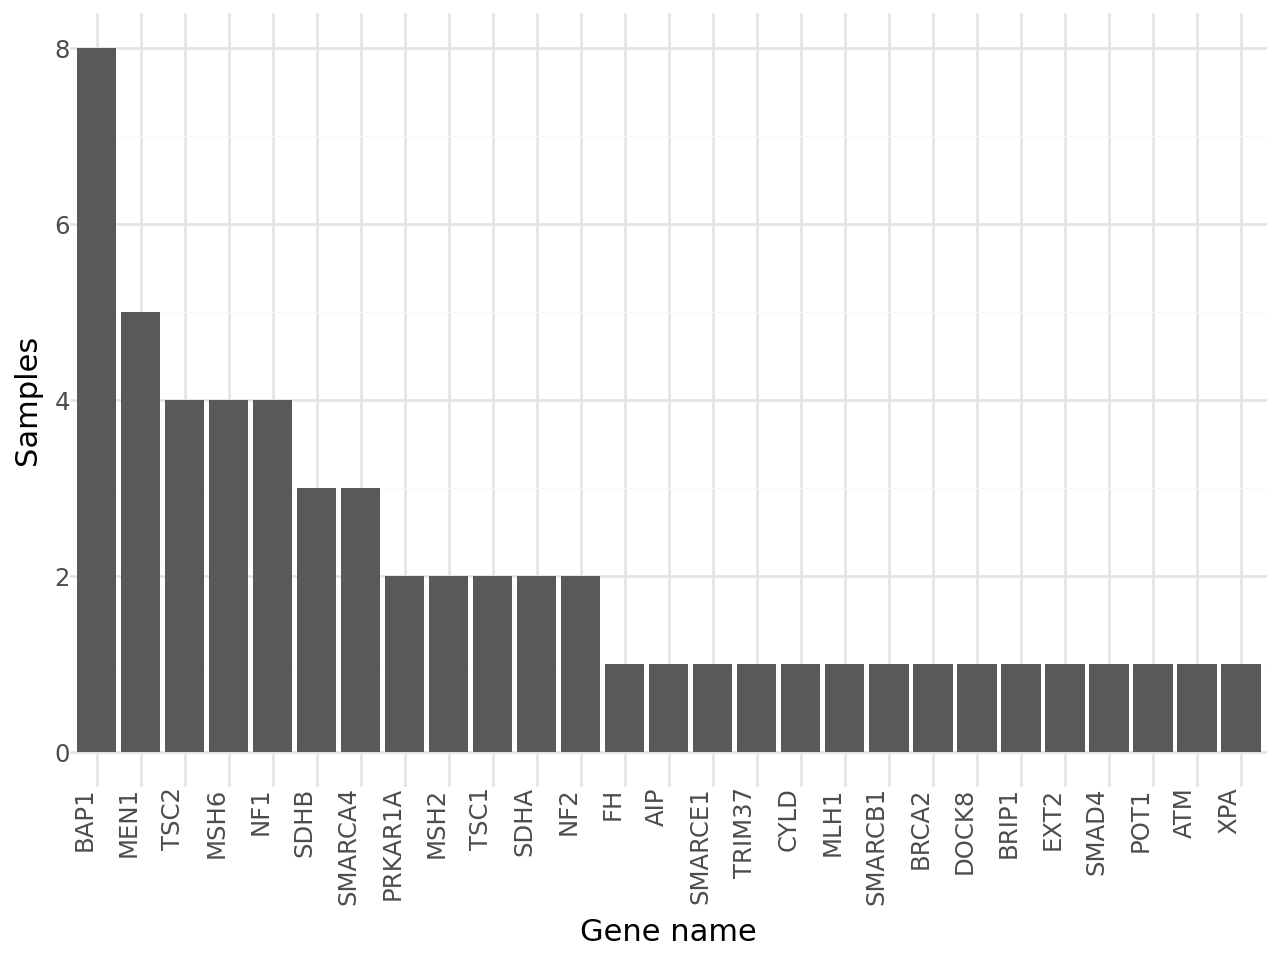

In [53]:
(
    pn.ggplot(counts, pn.aes(x='hgncSymbol', y='total_count')) +
    pn.geom_bar(stat='identity') +
    pn.labs(x= "Gene name", y="Samples") + 
    pn.theme_minimal() +
    pn.theme(axis_text_x=pn.element_text(rotation=90, hjust=1))
)

In [8]:
py_or_res_outliers_all_predisposed

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [55]:
py_or_res_outliers_all_predisposed["expression_direction"] = "underexpression"
py_or_res_outliers_all_predisposed.loc[py_or_res_outliers_all_predisposed["zScore"] >= 0, "expression_direction"] = "Overexpression"
py_or_res_outliers_all_predisposed[["geneID", "zScore", "pValue", "padjust", "Oncotree Code", "IMPACT", "Consequence", "gene_name", "ROLE_IN_CANCER", "expression_direction"]].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/py_outrider/gene_expression_outlier_predisposition_genes.tsv", sep="\t", index=None)



In [113]:

top_120_cohorts = list(py_or_res_outliers_all_predisposed["Oncotree Code"].value_counts()[0:120].index)

In [187]:
col_colors

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [190]:
cgc["ROLE_IN_CANCER_CLEAN"] = cgc["ROLE_IN_CANCER"].fillna("NA")
gene_roles = dict(zip(cgc["gene_name"], cgc["ROLE_IN_CANCER"]))

role_palette = {
    "oncogene": "red",
    "TSG": "green",
    "Non-cancer": "orange",
    "fusion": "purple",
    "NA": "gray",
}


col_colors = (
    heatmap_data.columns
    .to_series()
    .map(gene_roles)
    .fillna("Non-cancer")
    .map(role_palette)
)

(120, 123)


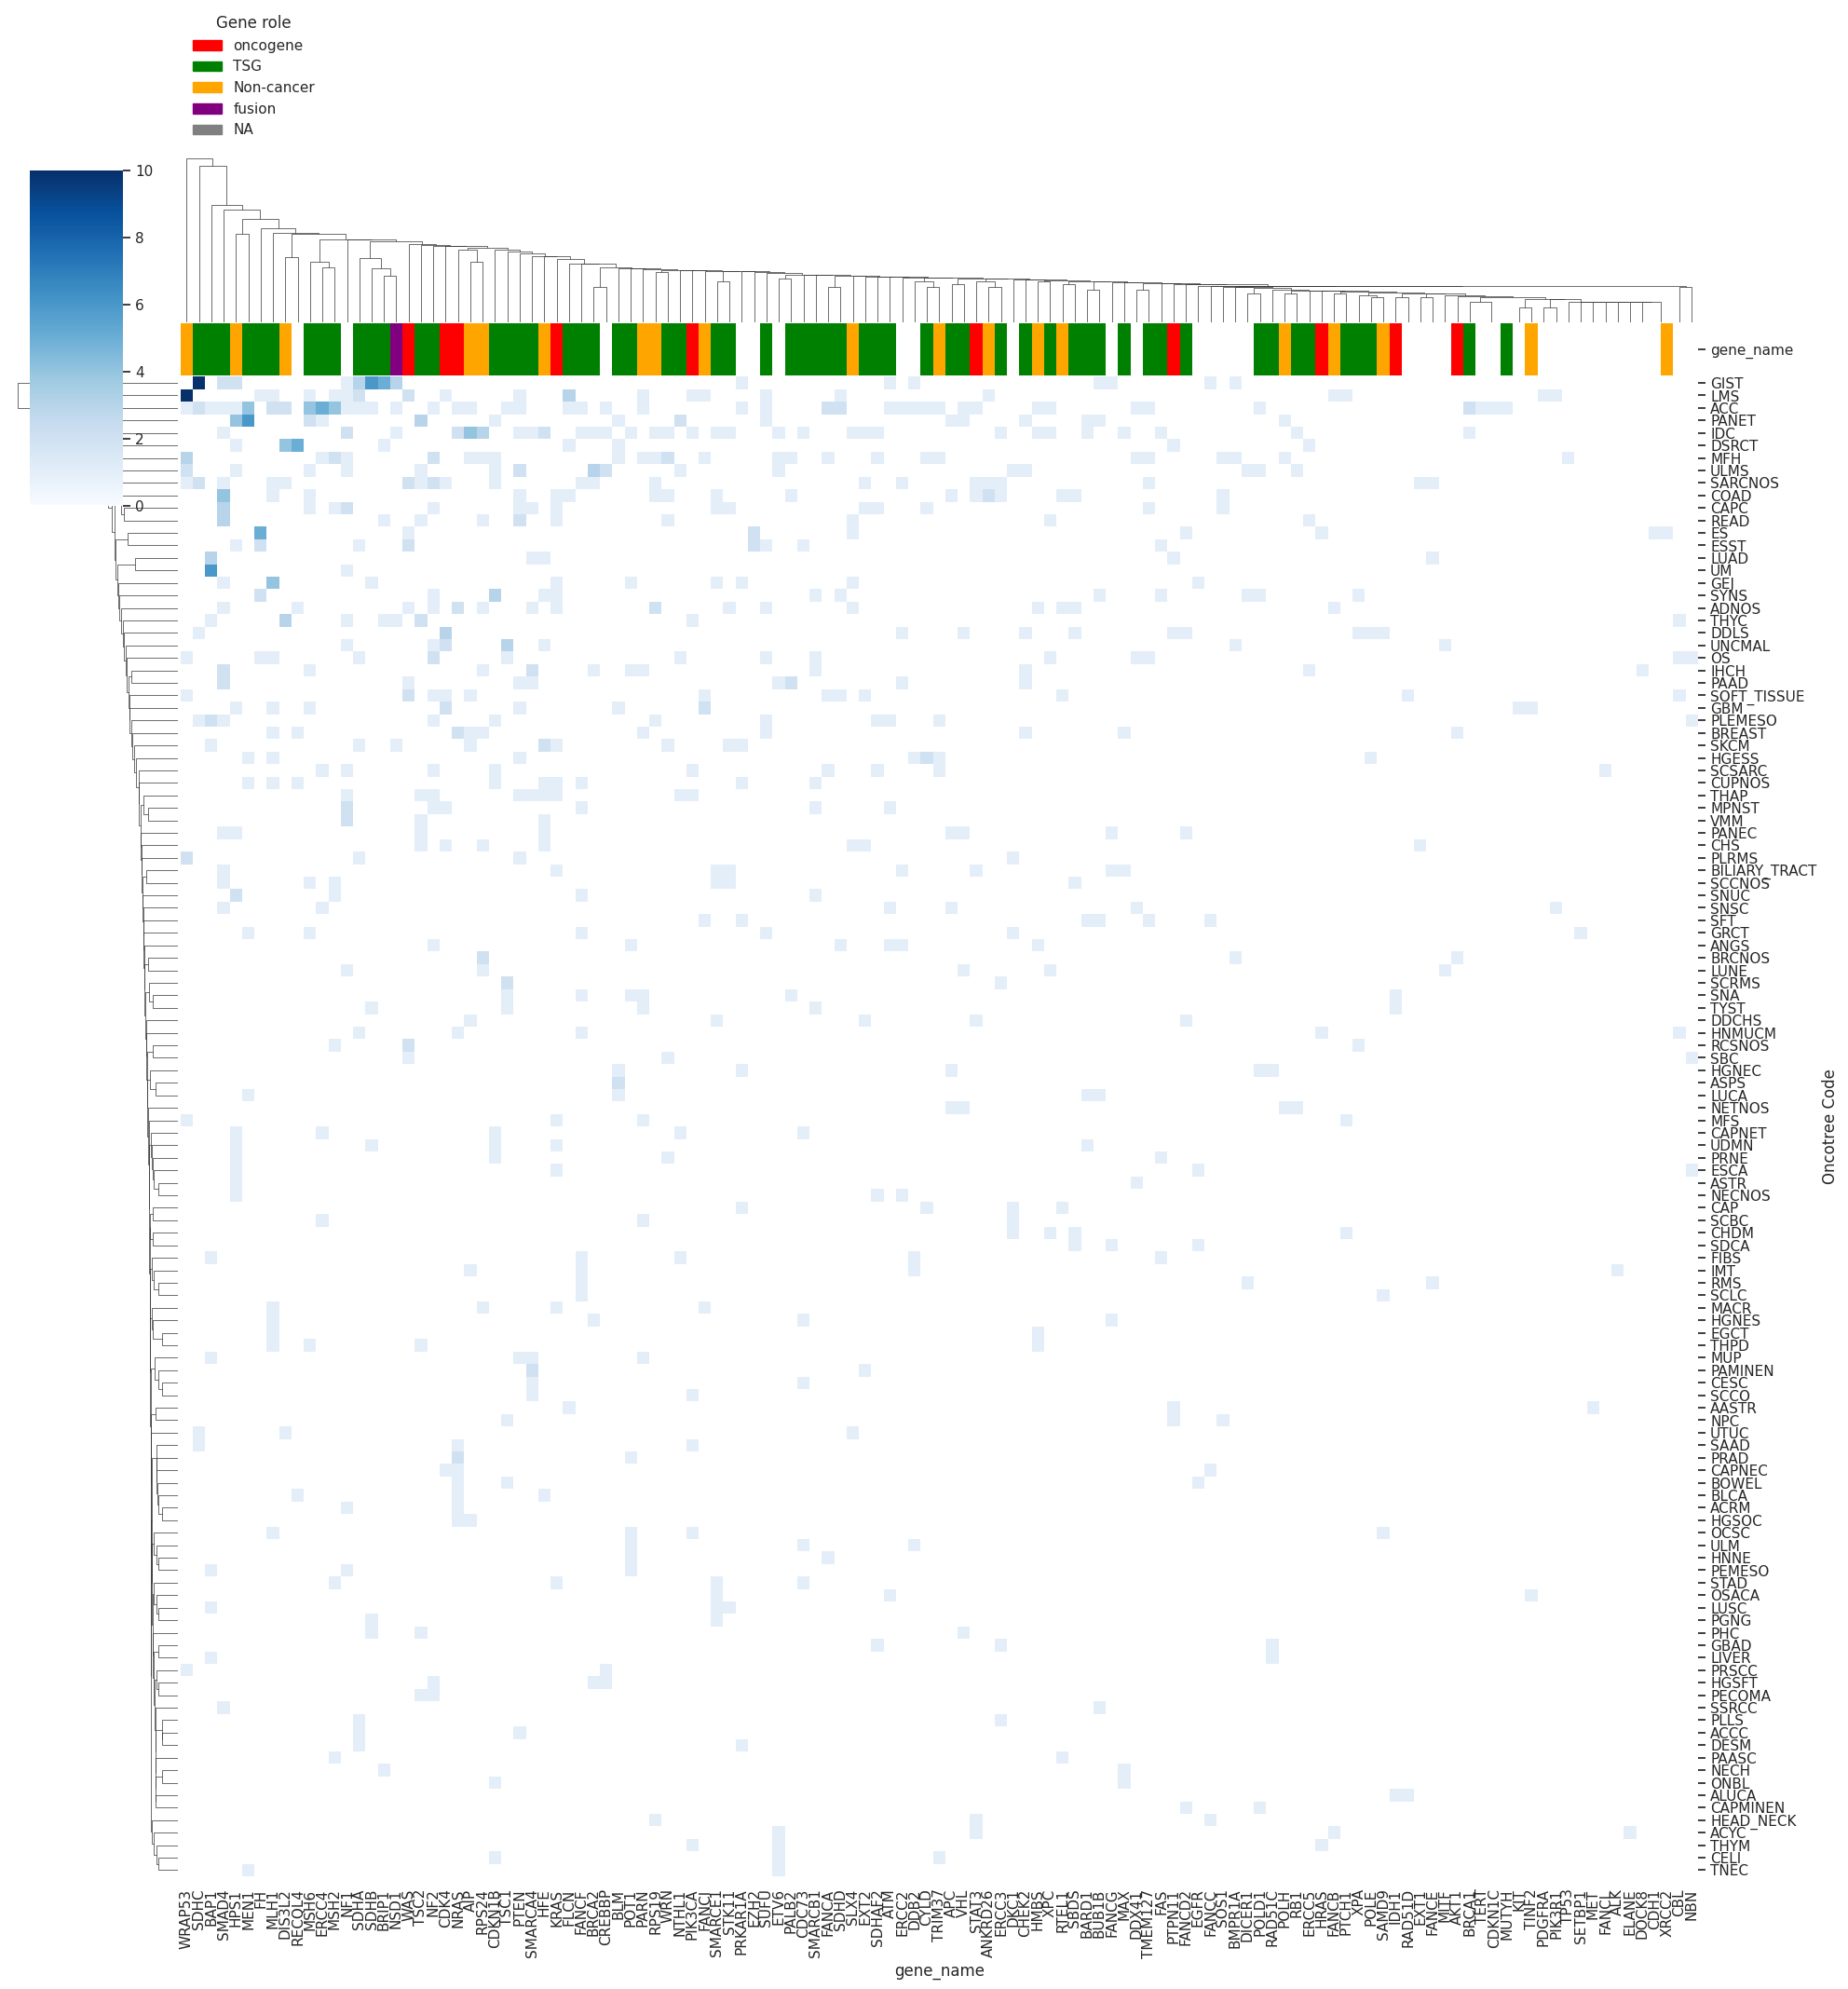

In [191]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

count_df = (
    py_or_res_outliers_all_predisposed[py_or_res_outliers_all_predisposed["Oncotree Code"].isin(top_120_cohorts)].groupby(["gene_name", "Oncotree Code"])["sampleID"]
      .nunique()            # or .count() if sample_id is unique already
      .reset_index()
)

# 2. Pivot to wide format for heatmap
heatmap_data = count_df.pivot(columns="gene_name", index="Oncotree Code", values="sampleID")
heatmap_data = heatmap_data.fillna(0)
print(heatmap_data.shape)

blue_cmap = sns.color_palette("Blues", as_cmap=True)
colors = blue_cmap(range(256))
colors[0] = [1.0, 1.0, 1.0, 1.0]      # force min value to white
custom_cmap = LinearSegmentedColormap.from_list("white_to_blues", colors)


sns.set(font_scale=1)

# 3. Plot
g = sns.clustermap(
    heatmap_data,
    cmap=custom_cmap,
    #figsize=(40, 12),      # wide figure to fit many genes
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.1),
    row_cluster=True,
    col_cluster=True,
    figsize=(20, 20),
    col_colors=col_colors
    #cbar_pos=(0.02, 0.8, 0.02, 0.15)  # adjust colorbar if needed
)

handles = [
    mpatches.Patch(color=color, label=role)
    for role, color in role_palette.items()
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="Gene role",
    loc="lower left",
    bbox_to_anchor=(0, 1),
    frameon=False
)

g.savefig("./gene_cohort_heatmap_discrete.png", dpi=300)

plt.show()
plt.close()

In [192]:
from matplotlib.colors import LinearSegmentedColormap

count_df = (
    py_or_res_outliers_all_predisposed[(py_or_res_outliers_all_predisposed["zScore"] < 0) & (py_or_res_outliers_all_predisposed["Oncotree Code"].isin(top_120_cohorts))].groupby(["gene_name", "Oncotree Code"])["sampleID"]
      .nunique()            # or .count() if sample_id is unique already
      .reset_index()
)

# 2. Pivot to wide format for heatmap
heatmap_data = count_df.pivot(columns="gene_name", index="Oncotree Code", values="sampleID")
heatmap_data = heatmap_data.fillna(0)

blue_cmap = sns.color_palette("Blues", as_cmap=True)
colors = blue_cmap(range(256))
colors[0] = [1.0, 1.0, 1.0, 1.0]      # force min value to white
custom_cmap = LinearSegmentedColormap.from_list("white_to_blues", colors)

sns.set(font_scale=1)

# 3. Plot
g = sns.clustermap(
    heatmap_data,
    cmap=custom_cmap,
    #figsize=(40, 12),      # wide figure to fit many genes
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.1),
    row_cluster=True,
    col_cluster=True,
    figsize=(20, 20),
    col_colors=col_colors
    #cbar_pos=(0.02, 0.8, 0.02, 0.15)  # adjust colorbar if needed
)
handles = [
    mpatches.Patch(color=color, label=role)
    for role, color in role_palette.items()
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="Gene role",
    loc="lower left",
    bbox_to_anchor=(0, 1),
    frameon=False
)
g.savefig("./gene_cohort_heatmap_underexpression.png", dpi=300)

#plt.show()
plt.close()

In [27]:
py_or_res_aberrant_predisposed_all["expression_direction"] = "underexpression"
py_or_res_aberrant_predisposed_all.loc[py_or_res_aberrant_predisposed_all["zScore"] >= 0, "expression_direction"] = "Overexpression"
py_or_res_aberrant_predisposed_all[["geneID", "zScore", "pValue", "padjust", "Oncotree Code", "IMPACT", "Consequence", "gene_name", "ROLE_IN_CANCER", "expression_direction", "predisposed_gene", "nct_pid", "RNA_BAM_FILE"]].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/py_outrider/gene_expression_outliers.tsv", sep="\t", index=None)

py_or_res_aberrant_predisposed = py_or_res_aberrant_predisposed_all[py_or_res_aberrant_predisposed_all["predisposed_gene"] != False]
py_or_res_aberrant_predisposed[["geneID", "zScore", "pValue", "padjust", "Oncotree Code", "IMPACT", "Consequence", "gene_name", "ROLE_IN_CANCER", "expression_direction", "predisposed_gene", "nct_pid", "RNA_BAM_FILE"]].to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/py_outrider/gene_expression_predisposition_outliers.tsv", sep="\t", index=None)


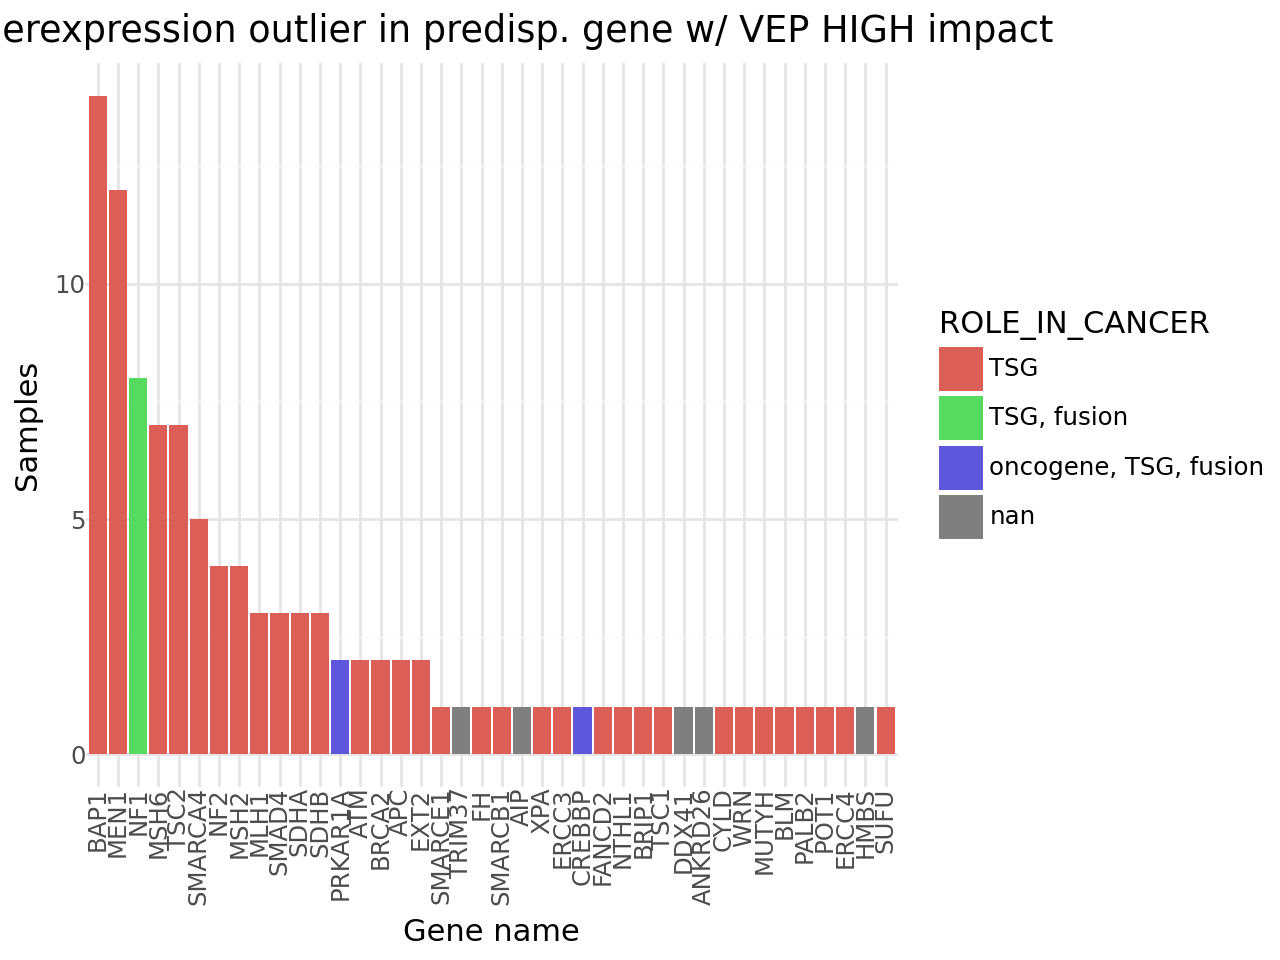

In [28]:

predisposed_high_impact_underexpressed = py_or_res_outliers_all_predisposed[(py_or_res_outliers_all_predisposed["zScore"] <= 0) & (py_or_res_outliers_all_predisposed["padjust"] <= 0.05) &(py_or_res_outliers_all_predisposed["IMPACT_bool"] == True)  ]

counts = (
    predisposed_high_impact_underexpressed['gene_name']
    .value_counts()                     # descending by default
    .reset_index(name='total_count')
    .rename(columns={'index':'gene_name'})
)
counts = counts.merge(cgc, on="gene_name", how="left")


# 2) set the categorical order so plot follows the descending counts
counts['gene_name'] = pd.Categorical(
    counts['gene_name'],
    categories=counts['gene_name'],    # already in descending order from value_counts()
    ordered=True
)

(
    pn.ggplot(counts, pn.aes(x='gene_name', y='total_count', fill="ROLE_IN_CANCER")) +
    pn.geom_bar(stat='identity') +
    pn.labs(x= "Gene name", y="Samples", title="Underexpression outlier in predisp. gene w/ VEP HIGH impact", size=8) + 
    pn.theme_minimal() +
    pn.theme(axis_text_x=pn.element_text(rotation=90))
)

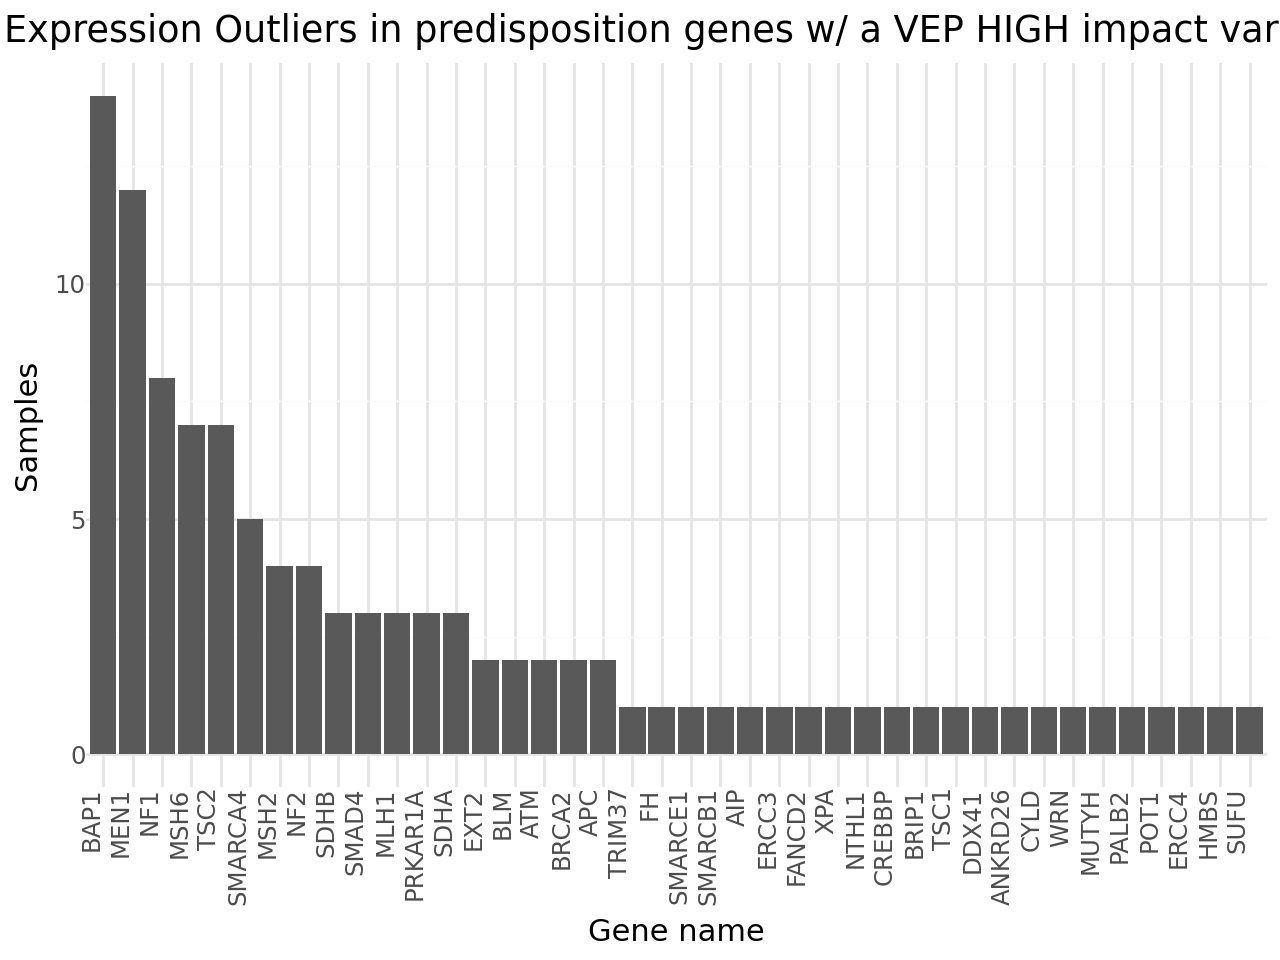

In [13]:
py_or_res_outliers_all_predisposed = pd.merge(py_or_res_aberrant, dresden_dt_cgc[["gene_name", "gene_type", "geneID", "ROLE_IN_CANCER"]], on="geneID")

predisposed_high_impact = py_or_res_outliers_all_predisposed[(py_or_res_outliers_all_predisposed["padjust"] <= 0.05) &(py_or_res_outliers_all_predisposed["IMPACT_bool"] == True)  ]

counts = (
    predisposed_high_impact['gene_name']
    .value_counts()                     # descending by default
    .reset_index(name='total_count')
    .rename(columns={'index':'gene_name'})
)

# 2) set the categorical order so plot follows the descending counts
counts['gene_name'] = pd.Categorical(
    counts['gene_name'],
    categories=counts['gene_name'],    # already in descending order from value_counts()
    ordered=True
)

(
    pn.ggplot(counts, pn.aes(x='gene_name', y='total_count')) +
    pn.geom_bar(stat='identity') +
    pn.labs(x= "Gene name", y="Samples", title="Expression Outliers in predisposition genes w/ a VEP HIGH impact variant") + 
    pn.theme_minimal() +
    pn.theme(axis_text_x=pn.element_text(rotation=90, hjust=1))
)

In [138]:
pr_samples = predisposed_high_impact_pr[predisposed_high_impact_pr["proteinID"].isin(common_pr_gene)]["sampleID"]

In [139]:
common_pr_gene = list(set(counts_pr["proteinID"]).intersection(set(counts["hgncSymbol"])))
predisposed_high_impact[(predisposed_high_impact["hgncSymbol"].isin(common_pr_gene)) & (predisposed_high_impact["sampleID"].isin(pr_samples))] 

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [140]:
predisposed_high_impact_pr[predisposed_high_impact_pr["proteinID"].isin(common_pr_gene)]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [1]:
predisposed_high_impact_pr[predisposed_high_impact_pr["IMPACT_bool"] == False]

NameError: name 'predisposed_high_impact_pr' is not defined

In [23]:
coad_or_res_predisposed = pd.merge(coad_or_res, dresden_dt_cgc[["gene_name", "gene_type", "geneID", "ROLE_IN_CANCER"]], on="geneID")

In [27]:
coad_or_res_predisposed[coad_or_res_predisposed["padjust"] <= 0.05]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [28]:
sum(coad_or_res[coad_or_res["padjust"] <= 0.05]["IMPACT_bool"])

22

In [8]:
coad_q_oht_aberrant = coad_q_oht[coad_q_oht["padjust"] <= 0.05]
coad_q_12_aberrant = coad_q_12[coad_q_12["padjust"] <= 0.05]
coad_or_res_aberrant = coad_or_res[coad_or_res["padjust"] <= 0.05]


In [14]:
sum(coad_q_oht_aberrant["IMPACT_bool"]), sum(coad_q_12_aberrant["IMPACT_bool"])


(23, 17)

In [20]:
len(set(coad_q_oht_aberrant.loc[coad_q_oht_aberrant["IMPACT_bool"] == True, "gene_sample"]).intersection(set(coad_q_12_aberrant.loc[coad_q_12_aberrant["IMPACT_bool"] == True, "gene_sample"])))

14

In [36]:
len(set(coad_q_oht_aberrant.loc[coad_q_oht_aberrant["IMPACT_bool"] == True, "gene_sample"]).intersection(set(coad_or_res_aberrant.loc[coad_or_res_aberrant["IMPACT_bool"] == True, "gene_sample"])))

21

In [13]:
py_or_res_all.columns

Index(['sampleID', 'geneID', 'PROTEIN_LOG2INT', 'PROTEIN_EXPECTED_LOG2INT',
       'PROTEIN_INT', 'zScore', 'pValue', 'padjust', 'PROTEIN_LOG2FC',
       'PROTEIN_FC', 'aberrant', 'pvalDistribution', 'Unnamed: 0', 'pid',
       'Oncotree Code', 'SEX', 'Birthdate', 'Deathdate', 'Date of Diagnosis',
       'ICD10 Code', 'freitext', 'Oncotree Text', 'Diagnosis valid',
       'Proteome data', 'ILSE IDs', 'MTB Date', 'ICD10_prefix', 'TISSUE',
       'DROP_GROUP', 'sample_type_base', 'sample_type', 'PAIRED_END', 'STRAND',
       'ratio', 'RNA_BAM_FILE', 'seq_type', 'DNA_VCF_FILE', 'RNA_ID', 'DNA_ID',
       'COUNT_MODE', 'COUNT_OVERLAPS', 'ANNOTATION', 'GENE_COUNTS_FILE',
       'oncotree_num', 'ICD10_num', 'tissue_num', 'indel_vcf', 'snv_vcf',
       'sv_vcf', 'cnv_vcf', 'bam_file', 'Diag', 'proteomics',
       'Tumorzellgehalt (Bioinformatik)', 'nct_pid', 'geneID_short',
       'expressed_in_cohort', 'gene_sample'],
      dtype='object')

In [ ]:
py_or_res_all['proportions'] = (
    py_or_res_all['IMPACT_bool'].eq(True).fillna(False).cumsum()
    / np.arange(1, len(py_or_res_all) + 1)
)

py_or_res_all['Rank'] = np.arange(1, len(py_or_res_all) + 1)
py_or_res_all['Method'] = "py_outrider_all_samples"
py_or_res_all['DROP_GROUP'] = "COAD"

# Underexpression subset
under_idx = py_or_res_all['zScore'] < 0
under = py_or_res_all.loc[under_idx].copy()

under_rank = np.arange(1, len(under) + 1)
under['underexpression_rank'] = under_rank

under_vus = (under['IMPACT_bool'].to_numpy() == True)
x = np.cumsum(under_vus)

under['underexpression_proportions'] = x / under_rank

# Vectorized Clopper–Pearson
alpha = 0.05
under['ci_min'] = beta.ppf(alpha/2, x, under_rank - x + 1)
under['ci_max'] = beta.ppf(1 - alpha/2, x + 1, under_rank - x)

# Efficient vectorized assignment (NO MERGE)
py_or_res_all.loc[under_idx, [
    "underexpression_proportions",
    "underexpression_rank",
    "ci_min",
    "ci_max"
]] = under[
    ["underexpression_proportions", "underexpression_rank", "ci_min", "ci_max"]
].to_numpy()

In [ ]:
p2 = (
    pn.ggplot(py_or_res_all[(py_or_res_all["zScore"] < 0) & (py_or_res_all["underexpression_rank"] > 100) & (py_or_res_all["underexpression_rank"] < 1e8)], pn.aes(x="underexpression_rank", 
                   y="underexpression_proportions", 
                   color="Method"))
    + pn.geom_line()
    + pn.scale_x_log10()
    + pn.annotation_logticks(sides="b")
    + pn.labs(
        y="Proportion of underexpression outliers\nwith rare variants",
        x="Outlier rank cutoff"
    )
    + pn.theme_bw(base_size=12)
    #+ pn.facet_grid(". ~ plot_title")
)
p2

In [49]:
coad_or_res['proportions'] = (
    coad_or_res['IMPACT_bool'].eq(True).fillna(False).cumsum()
    / np.arange(1, len(coad_or_res) + 1)
)

coad_or_res['Rank'] = np.arange(1, len(coad_or_res) + 1)
coad_or_res['Method'] = "OUTRIDER"
coad_or_res['DROP_GROUP'] = "COAD"

# Underexpression subset
under_idx = coad_or_res['zScore'] < 0
under = coad_or_res.loc[under_idx].copy()

under_rank = np.arange(1, len(under) + 1)
under['underexpression_rank'] = under_rank

under_vus = (under['IMPACT_bool'].to_numpy() == True)
x = np.cumsum(under_vus)

under['underexpression_proportions'] = x / under_rank

# Vectorized Clopper–Pearson
alpha = 0.05
under['ci_min'] = beta.ppf(alpha/2, x, under_rank - x + 1)
under['ci_max'] = beta.ppf(1 - alpha/2, x + 1, under_rank - x)

# Efficient vectorized assignment (NO MERGE)
coad_or_res.loc[under_idx, [
    "underexpression_proportions",
    "underexpression_rank",
    "ci_min",
    "ci_max"
]] = under[
    ["underexpression_proportions", "underexpression_rank", "ci_min", "ci_max"]
].to_numpy()

In [51]:
coad_q_oht['proportions'] = (
    coad_q_oht['IMPACT_bool'].eq(True).fillna(False).cumsum()
    / np.arange(1, len(coad_q_oht) + 1)
)

coad_q_oht['Rank'] = np.arange(1, len(coad_q_oht) + 1)
coad_q_oht['Method'] = "py_outrider"
coad_q_oht['DROP_GROUP'] = "COAD"

# Underexpression subset
under_idx = coad_q_oht['zScore'] < 0
under = coad_q_oht.loc[under_idx].copy()

under_rank = np.arange(1, len(under) + 1)
under['underexpression_rank'] = under_rank

under_vus = (under['IMPACT_bool'].to_numpy() == True)
x = np.cumsum(under_vus)

under['underexpression_proportions'] = x / under_rank

# Vectorized Clopper–Pearson
alpha = 0.05
under['ci_min'] = beta.ppf(alpha/2, x, under_rank - x + 1)
under['ci_max'] = beta.ppf(1 - alpha/2, x + 1, under_rank - x)

# Efficient vectorized assignment (NO MERGE)
coad_q_oht.loc[under_idx, [
    "underexpression_proportions",
    "underexpression_rank",
    "ci_min",
    "ci_max"
]] = under[
    ["underexpression_proportions", "underexpression_rank", "ci_min", "ci_max"]
].to_numpy()

In [65]:
py_or_res_all_coad['proportions'] = (
    py_or_res_all_coad['IMPACT_bool'].eq(True).fillna(False).cumsum()
    / np.arange(1, len(py_or_res_all_coad) + 1)
)

py_or_res_all_coad['Rank'] = np.arange(1, len(py_or_res_all_coad) + 1)
py_or_res_all_coad['Method'] = "py_outrider_all_samples"
py_or_res_all_coad['DROP_GROUP'] = "COAD"

# Underexpression subset
under_idx = py_or_res_all_coad['zScore'] < 0
under = py_or_res_all_coad.loc[under_idx].copy()

under_rank = np.arange(1, len(under) + 1)
under['underexpression_rank'] = under_rank

under_vus = (under['IMPACT_bool'].to_numpy() == True)
x = np.cumsum(under_vus)

under['underexpression_proportions'] = x / under_rank

# Vectorized Clopper–Pearson
alpha = 0.05
under['ci_min'] = beta.ppf(alpha/2, x, under_rank - x + 1)
under['ci_max'] = beta.ppf(1 - alpha/2, x + 1, under_rank - x)

# Efficient vectorized assignment (NO MERGE)
py_or_res_all_coad.loc[under_idx, [
    "underexpression_proportions",
    "underexpression_rank",
    "ci_min",
    "ci_max"
]] = under[
    ["underexpression_proportions", "underexpression_rank", "ci_min", "ci_max"]
].to_numpy()

In [66]:
res_combined = pd.concat([coad_q_oht, coad_or_res, py_or_res_all_coad], ignore_index=True)

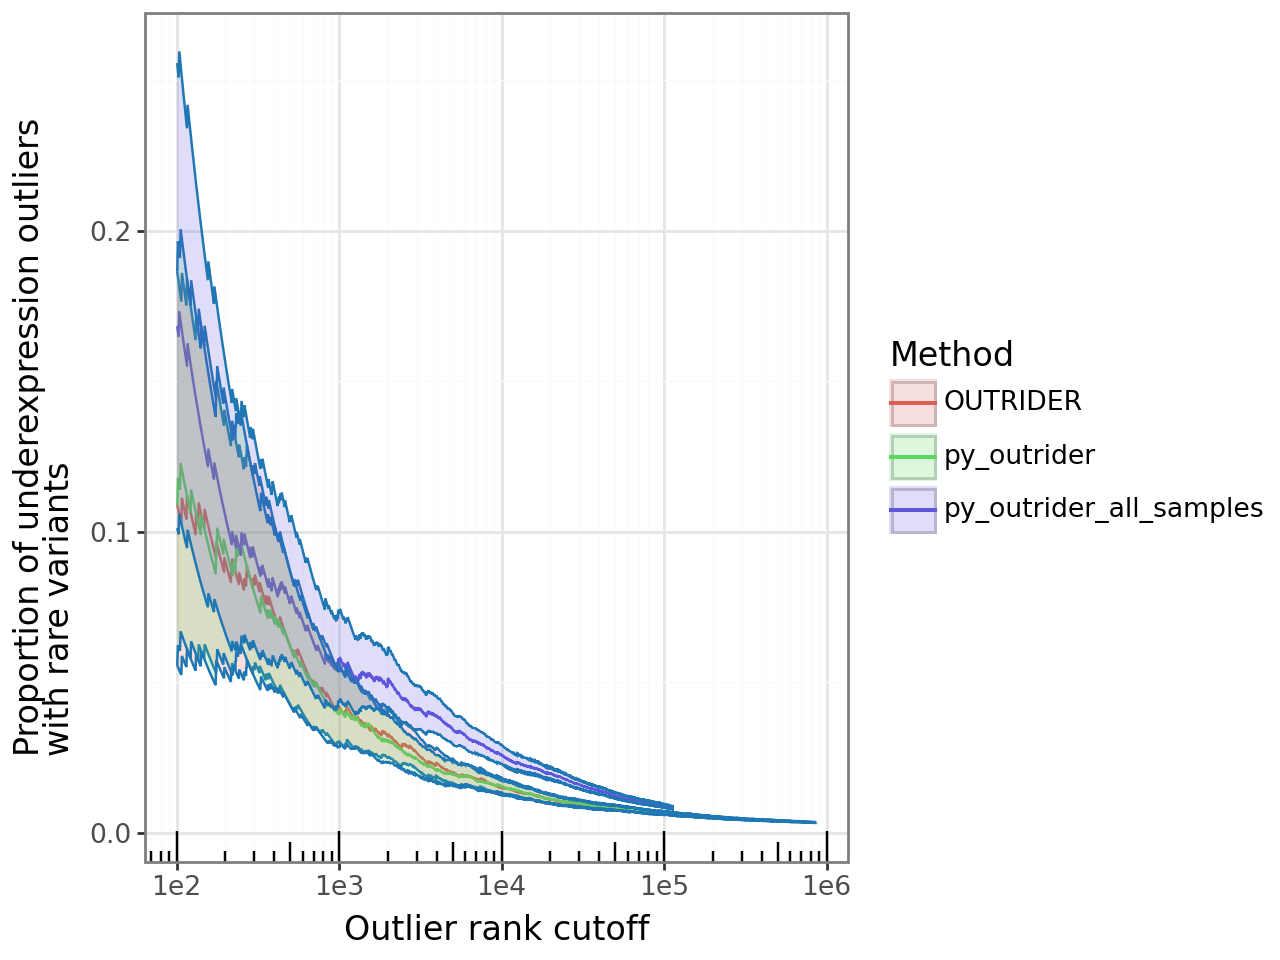

In [67]:
p3 = (
    pn.ggplot(res_combined[(res_combined["zScore"] < 0) & (res_combined["underexpression_rank"] > 100) & (res_combined["underexpression_rank"] < 1e8)], pn.aes(x="underexpression_rank", 
                   y="underexpression_proportions", 
                   color="Method"))
    + pn.geom_line()
    + pn.geom_ribbon(
        pn.aes(ymin="ci_min", ymax="ci_max", fill="Method"),
        alpha=0.20,
        color=None
    )
    + pn.scale_x_log10()
    + pn.annotation_logticks(sides="b")
    + pn.labs(
        y="Proportion of underexpression outliers\nwith rare variants",
        x="Outlier rank cutoff"
    )
    + pn.theme_bw(base_size=12)
    #+ pn.facet_grid(". ~ plot_title")
)
p3

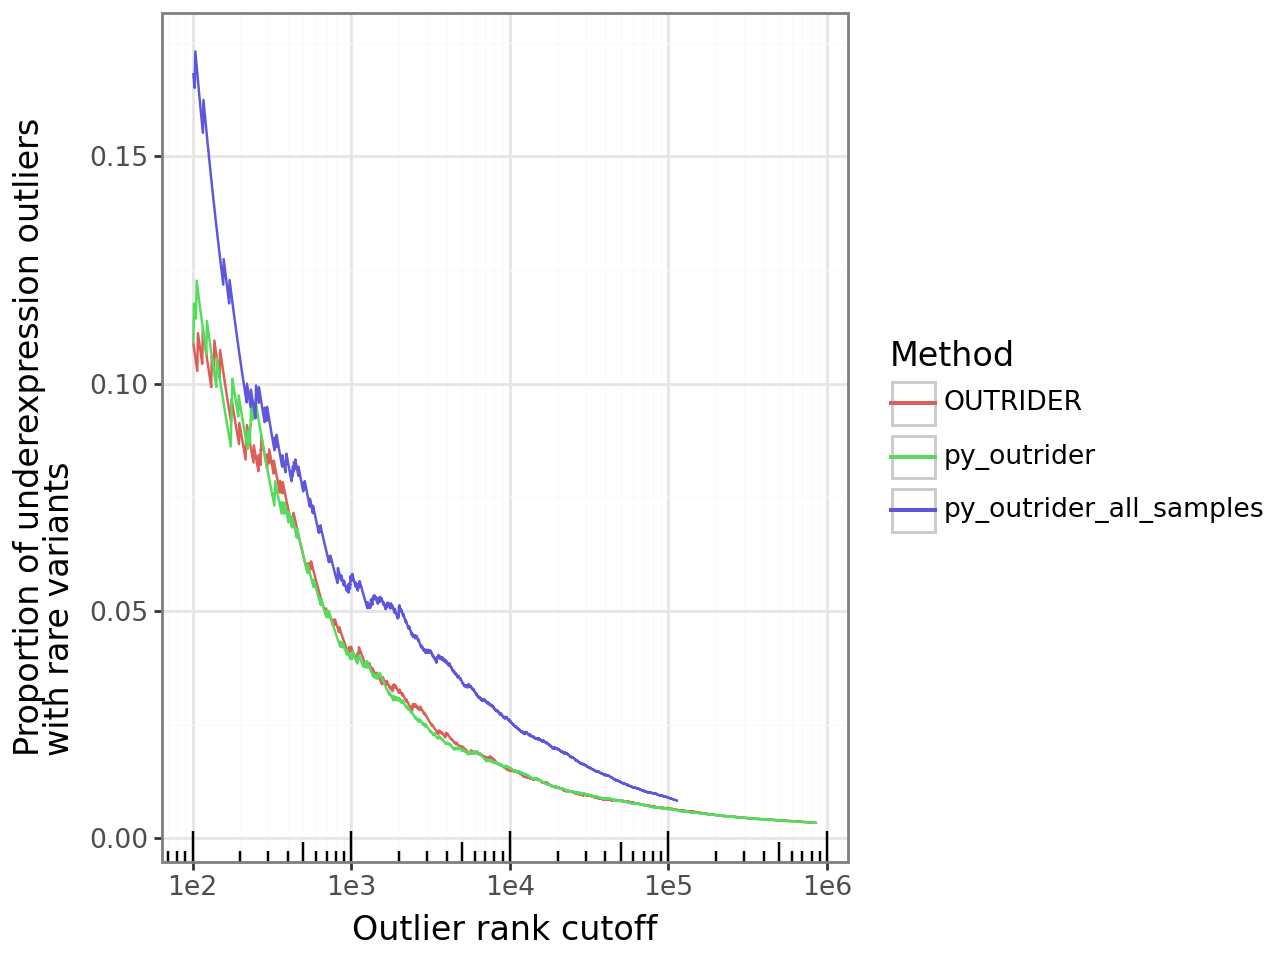

In [68]:
p2 = (
    pn.ggplot(res_combined[(res_combined["zScore"] < 0) & (res_combined["underexpression_rank"] > 100) & (res_combined["underexpression_rank"] < 1e8)], pn.aes(x="underexpression_rank", 
                   y="underexpression_proportions", 
                   color="Method"))
    + pn.geom_line()
    + pn.scale_x_log10()
    + pn.annotation_logticks(sides="b")
    + pn.labs(
        y="Proportion of underexpression outliers\nwith rare variants",
        x="Outlier rank cutoff"
    )
    + pn.theme_bw(base_size=12)
    #+ pn.facet_grid(". ~ plot_title")
)
p2

In [119]:
or_significant, py_or_all_significant

(201, 885)

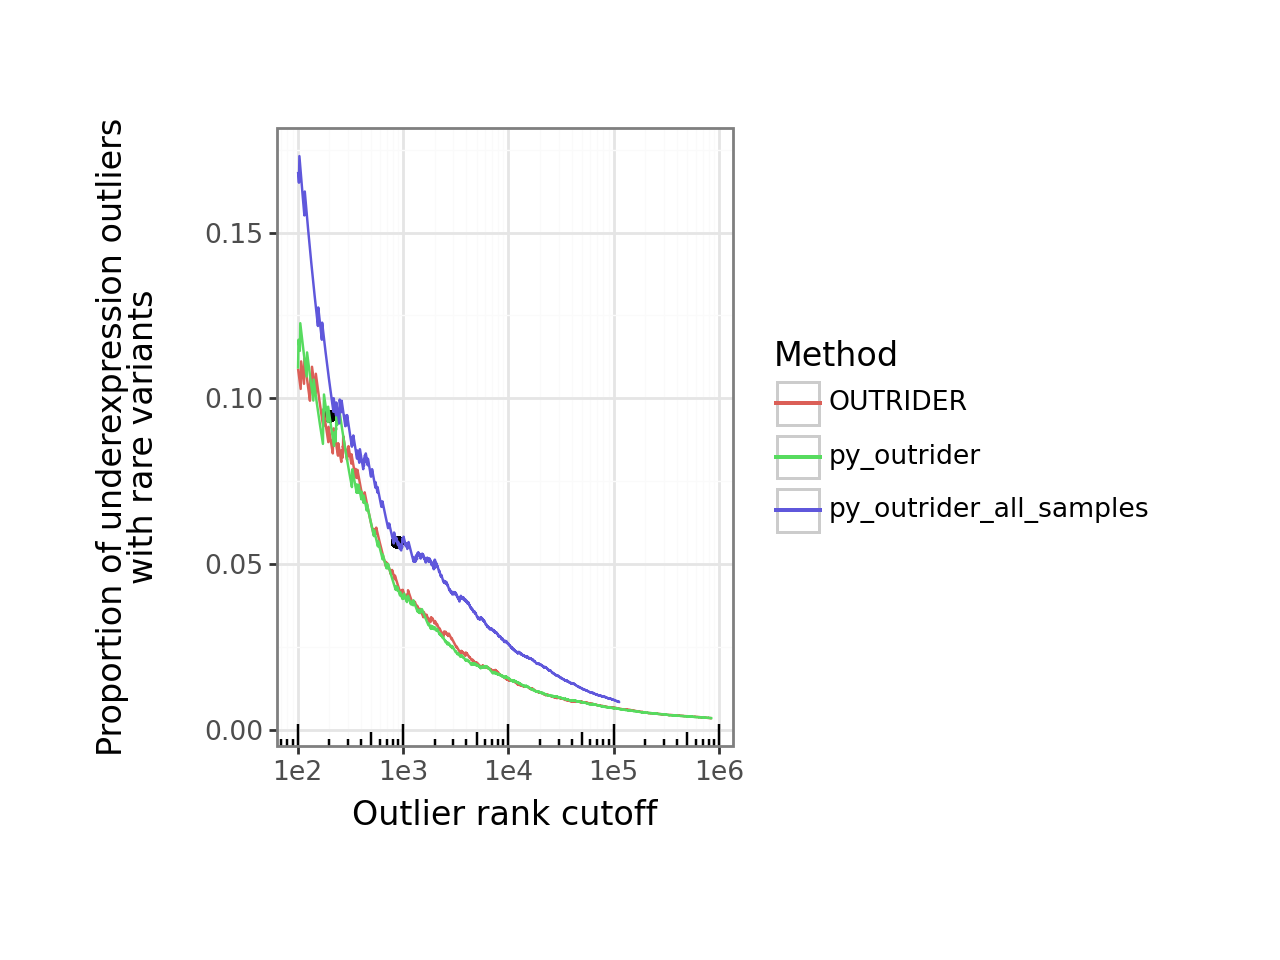

In [117]:
py_or_all_significant = len(py_or_res_all_coad[(py_or_res_all_coad["padjust"] <= 0.05) & (py_or_res_all_coad["zScore"] < 0)])
py_or_all_significant_prop = py_or_res_all_coad[py_or_res_all_coad["underexpression_rank"] == py_or_all_significant]["underexpression_proportions"].values[0]

or_significant = len(coad_q_oht[(coad_q_oht["padjust"] <= 0.05) & (coad_q_oht["zScore"] < 0)])
or_significant_prop = coad_q_oht[coad_q_oht["underexpression_rank"] == or_significant]["underexpression_proportions"].values[0]


p2 = (
    pn.ggplot(res_combined[(res_combined["zScore"] < 0) & (res_combined["underexpression_rank"] > 100) & (res_combined["underexpression_rank"] < 1e7)], pn.aes(x="underexpression_rank", 
                   y="underexpression_proportions", 
                   color="Method"))
    + pn.geom_point(pn.aes(y = py_or_all_significant_prop, x = py_or_all_significant, ), color="black")
    + pn.geom_point(pn.aes(y = or_significant_prop, x = or_significant, ), color="black")
    + pn.geom_line()
    + pn.scale_x_log10()
    + pn.annotation_logticks(sides="b")
    + pn.labs(
        y="Proportion of underexpression outliers\nwith rare variants",
        x="Outlier rank cutoff"
    ) 
    
    + pn.theme_bw(base_size=12) 
    + pn.theme(
        plot_margin=0.1,
        axis_title_y = pn.element_text(
            va="center" ,
            ha="center",# vertical alignment
        )
    )

    #+ pn.facet_grid(". ~ plot_title")
)
p2

In [118]:
p2.save("./png.png", dpi=600, width=8, height=5, units="in")

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 5 in image.
/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ./png.png
